In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from copy import copy
import scipy
from zsindy.ml_module import ZSindy
import pysindy

( x )' =  + -0.1228 x**2 + 0.0000 x*y**3 + 0.0006 x**4*y
( y )' =  + 0.1733 x**4 + -0.0321 x**5 + -0.0021 x**4*y


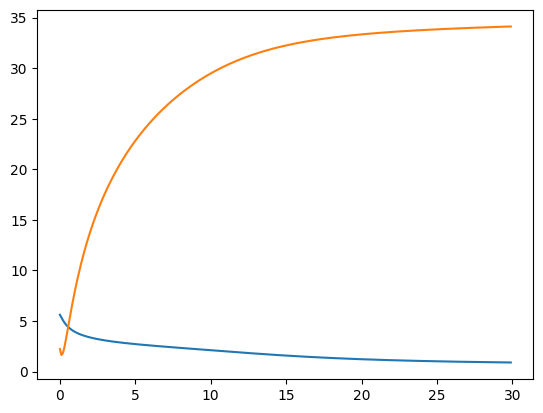

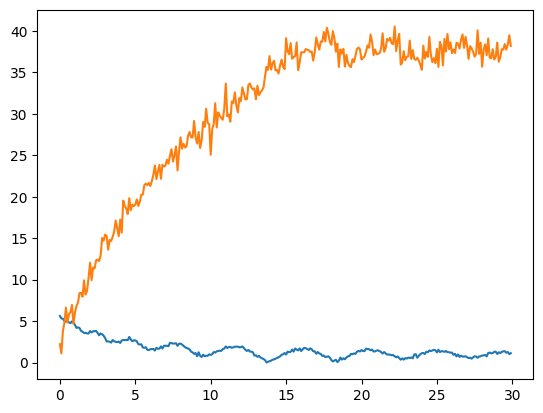

In [2]:
data = pd.read_csv('datasets/glider_SNR_20_0.csv')

X = data[['x','y']].to_numpy()

t = data['t'].to_numpy()

x0 = X[0]
poly_degree = 5

# Zsindy parameters
e_ensemble_trials = 10
z_ensemble_trials = e_ensemble_trials
rho = 0.00001 # Resolution ¿error? hyperparameter
zsindy_num_terms = 5
lmbda = 1e5
varnames = ['x','y']

## Z-Sindy
zmodel = ZSindy(poly_degree=poly_degree,
                variable_names=varnames)

zmodel.fit(X, t)

zmodel.print()
z_x_pred = zmodel.simulate(x0, t)
z_xdot_pred = zmodel.predict()

plt.plot(t,z_x_pred)

plt.show()
plt.plot(t,X)
plt.show()

(x)' = 0.021 x + -0.055 xx
(y)' = 116.590 1 + -154.392 x + -4.737 y + 55.603 xx + 0.045 yy + 5.203 xy + -1.040 xxy + -0.038 xyy + -5.806 xxx
[[ 0.00000000e+00  2.06643336e-02  0.00000000e+00 -5.48866056e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.16589842e+02 -1.54391914e+02 -4.73664331e+00  5.56030733e+01
   4.45738616e-02  5.20318952e+00 -1.04025861e+00 -3.76275054e-02
  -5.80649289e+00  0.00000000e+00]]


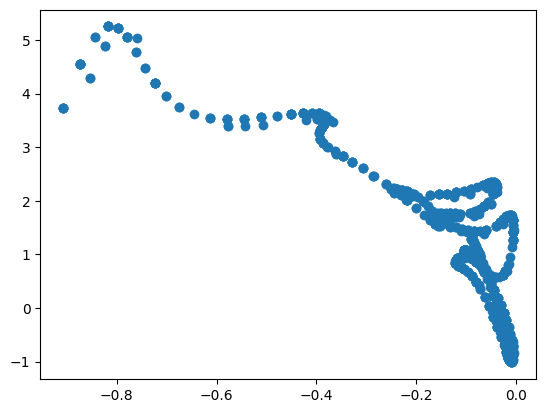

capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


IndexError: index 126 is out of bounds for axis 0 with size 1

In [3]:
n_models=1000
library_functions = [lambda x: x, lambda x: x * x, lambda x, y: x * y,
                     lambda x, y: x * x * y,lambda x, y: x * y * y,lambda x: x * x * x]
library_function_names = [lambda x: x,lambda x: x+x,lambda x, y: x+y,
                     lambda x, y: x+x+y,lambda x, y: x + y + y,lambda x: x + x + x]
feature_names = ['x','y']
ensemble_optimizer = pysindy.STLSQ(threshold=1e-2)

weak_lib = pysindy.WeakPDELibrary(
    library_functions=library_functions,
    function_names=library_function_names,
    include_bias=True,
    spatiotemporal_grid=data.t.to_numpy(),
    is_uniform=True,
    K=1000,
)

# SINDy initialization
model = pysindy.SINDy(
    feature_names=feature_names,
    feature_library=weak_lib,
    optimizer=ensemble_optimizer,
)
model.fit(
    X,
    ensemble=True,
    n_models=n_models,
    quiet=True
)
model.print()
print(model.coefficients())

pred = model.predict(X)

plt.scatter(pred[:,0],pred[:,1])
plt.show()
z_x_pred = model.simulate(x0, t)
plt.plot(t,z_x_pred)
plt.show()

(x)' = -0.148 x
(y)' = 3.574 1 + -33.224 x + 0.646 y + 16.406 x^2 + 0.748 x y + -0.019 y^2 + -1.878 x^3 + -0.270 x^2 y
[[ 0.00000000e+00 -1.47933201e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 3.57429090e+00 -3.32239772e+01  6.46336567e-01  1.64064566e+01
   7.47670675e-01 -1.92392894e-02 -1.87752904e+00 -2.69559942e-01
   0.00000000e+00  0.00000000e+00]]


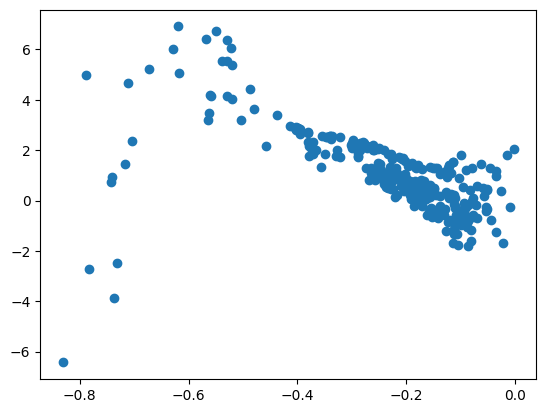

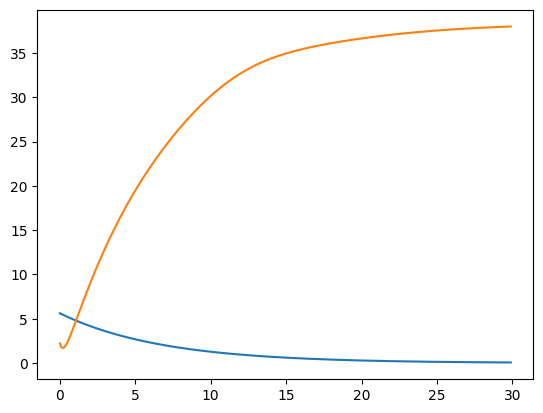

In [4]:
n_models=1000
ensemble_optimizer = pysindy.STLSQ(threshold=1e-2)
poly_library = pysindy.PolynomialLibrary(degree=3, include_bias=True)
model = pysindy.SINDy(
    feature_names=['x','y'],
    feature_library=poly_library,
    optimizer=ensemble_optimizer,
)
h= data.t[1] - data.t[0]
model.fit(X, t=h, ensemble=True, n_models=n_models, quiet=True)

model.print()
print(model.coefficients())

pred = model.predict(X)

plt.scatter(pred[:,0],pred[:,1])
plt.show()

z_x_pred = model.simulate(x0, t)
plt.plot(t,z_x_pred)
plt.show()